In [411]:
import tensorflow as tf
import h5py
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D
import matplotlib.pyplot as plt

dataset_link : https://www.kaggle.com/datasets/maneesh99/signs-detection-dataset/data

In [412]:
file_train = h5py.File("Signs_Data_Training.h5")
file_test = h5py.File("Signs_Data_Testing.h5")

file_train.keys()

<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>

In [413]:
file_test.keys()

<KeysViewHDF5 ['list_classes', 'test_set_x', 'test_set_y']>

In [414]:
x_train = file_train["train_set_x"][:]
y_train = file_train["train_set_y"][:]

c1 = file_train["list_classes"][:]

c2 = file_test["list_classes"][:]

x_test = file_test["test_set_x"][:]
y_test = file_test["test_set_y"][:]

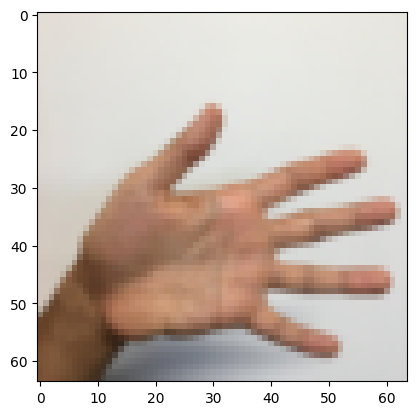

In [415]:
plt.imshow(x_train[0])

In [416]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [417]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [418]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(6))

In [419]:
model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_135 (Conv2D)         (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_119 (MaxPooli  (None, 31, 31, 32)       0         
 ng2D)                                                           
                                                                 
 conv2d_136 (Conv2D)         (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_120 (MaxPooli  (None, 14, 14, 64)       0         
 ng2D)                                                           
                                                                 
 conv2d_137 (Conv2D)         (None, 12, 12, 64)        36928     
                                                                 
 flatten_58 (Flatten)        (None, 9216)            

In [420]:
model.compile(optimizer='adam',
              #loss=tf.keras.losses.CategoricalCrossentropy(),
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [421]:
history = model.fit(x_train, y_train, epochs=100, validation_split=0.3 , batch_size=128)

Epoch 1/100
6/6 [==============================] - 1s 61ms/step - loss: 1.8200 - accuracy: 0.1786 - val_loss: 1.7894 - val_accuracy: 0.1667
Epoch 2/100
6/6 [==============================] - 0s 32ms/step - loss: 1.7817 - accuracy: 0.1878 - val_loss: 1.7727 - val_accuracy: 0.1667
Epoch 3/100
6/6 [==============================] - 0s 33ms/step - loss: 1.7459 - accuracy: 0.2526 - val_loss: 1.7016 - val_accuracy: 0.3148
Epoch 4/100
6/6 [==============================] - 0s 33ms/step - loss: 1.6687 - accuracy: 0.3029 - val_loss: 1.6340 - val_accuracy: 0.2346
Epoch 5/100
6/6 [==============================] - 0s 33ms/step - loss: 1.5537 - accuracy: 0.3571 - val_loss: 1.4451 - val_accuracy: 0.4753
Epoch 6/100
6/6 [==============================] - 0s 32ms/step - loss: 1.3487 - accuracy: 0.4934 - val_loss: 1.2532 - val_accuracy: 0.5556
Epoch 7/100
6/6 [==============================] - 0s 33ms/step - loss: 1.1366 - accuracy: 0.5820 - val_loss: 1.1966 - val_accuracy: 0.5556
Epoch 8/100
6/6 [===

4/4 - 0s - loss: 0.4399 - accuracy: 0.9083 - 28ms/epoch - 7ms/step


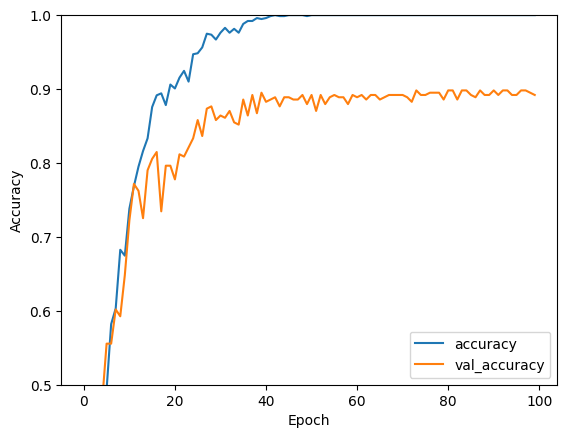

In [422]:

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

In [423]:
from sklearn.metrics import classification_report,roc_curve,roc_auc_score
import numpy as np

In [424]:
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred,axis=1)
print(classification_report(y_pred=y_pred,y_true=y_test))

4/4 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.95      0.95      0.95        20
           2       1.00      0.85      0.92        20
           3       0.90      0.95      0.93        20
           4       0.82      0.90      0.86        20
           5       0.81      0.85      0.83        20

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120



In [425]:
from tensorflow.keras.layers import Add,ReLU

**use function model and skip connection and use dropout and BatchNormalization and applying callbacks and visualize fliter**

In [426]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model

#dimensionality of input and latent encoded representations
inpt_dim = (64,64,3)
inpt_img= Input(shape=inpt_dim)
#Convolutional layer
c11 = Conv2D(64,(9,9), strides=(2,2), input_shape = inpt_dim, activation='relu')(inpt_img)
#Pooling and BatchNorm
bn13 = BatchNormalization()(c11)
p12 = MaxPooling2D(pool_size = (2,2))(bn13)

skip = p12

# Add a second convolutional layer
c14 = Conv2D(64,(9,9), strides=(1,1), activation='relu',padding="same")(p12)
bn16 = BatchNormalization()(c14)


skip = Add()([skip,bn16])


p15 = MaxPooling2D(pool_size = (2,2))(skip)


# Flattening for compatibility
f17 = Flatten()(p15)
#Dense layers
d19 = Dense(units = 32,activation = 'relu')(f17)
do110 = Dropout(0.3)(d19)
output= Dense(units = 6, activation='softmax')(do110)

classifier = Model(inpt_img, output)

In [427]:
classifier.compile(optimizer="adam", loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=['accuracy'])
print(classifier.summary())

Model: "model_46"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_52 (InputLayer)          [(None, 64, 64, 3)]  0           []                               
                                                                                                  
 conv2d_138 (Conv2D)            (None, 28, 28, 64)   15616       ['input_52[0][0]']               
                                                                                                  
 batch_normalization_106 (Batch  (None, 28, 28, 64)  256         ['conv2d_138[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 max_pooling2d_121 (MaxPooling2  (None, 14, 14, 64)  0           ['batch_normalization_106[

In [428]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, 
                              min_delta=1e-4, mode='min', verbose=1)

stop_alg = EarlyStopping(monitor='val_loss', patience=30, 
                         restore_best_weights=True, verbose=1)

checkpoint_filepath = 'cnn_model.h5'
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

hist = classifier.fit(x_train, y_train, batch_size=64, epochs=100, 
                   callbacks=[stop_alg, reduce_lr, model_checkpoint], shuffle=True, 
                   validation_split=0.3)

Epoch 1/100
12/12 [==============================] - 1s 37ms/step - loss: 2.4986 - accuracy: 0.2037 - val_loss: 1.9058 - val_accuracy: 0.1605 - lr: 0.0010
Epoch 2/100
12/12 [==============================] - 0s 24ms/step - loss: 1.6793 - accuracy: 0.2368 - val_loss: 1.9502 - val_accuracy: 0.1636 - lr: 0.0010
Epoch 3/100
12/12 [==============================] - 0s 24ms/step - loss: 1.5336 - accuracy: 0.3241 - val_loss: 1.8971 - val_accuracy: 0.1667 - lr: 0.0010
Epoch 4/100
12/12 [==============================] - 0s 24ms/step - loss: 1.4039 - accuracy: 0.3968 - val_loss: 1.7409 - val_accuracy: 0.1728 - lr: 0.0010
Epoch 5/100
12/12 [==============================] - 0s 24ms/step - loss: 1.2879 - accuracy: 0.4524 - val_loss: 1.7178 - val_accuracy: 0.2130 - lr: 0.0010
Epoch 6/100
12/12 [==============================] - 0s 24ms/step - loss: 1.2046 - accuracy: 0.5066 - val_loss: 1.8277 - val_accuracy: 0.2623 - lr: 0.0010
Epoch 7/100
12/12 [==============================] - 0s 21ms/step - lo

In [429]:
y_pred = classifier.predict(x_test)
y_pred = np.argmax(y_pred,axis=1)
print(classification_report(y_pred=y_pred,y_true=y_test))

4/4 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.91      1.00      0.95        20
           2       1.00      0.90      0.95        20
           3       0.95      1.00      0.98        20
           4       1.00      0.90      0.95        20
           5       0.95      1.00      0.98        20

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120



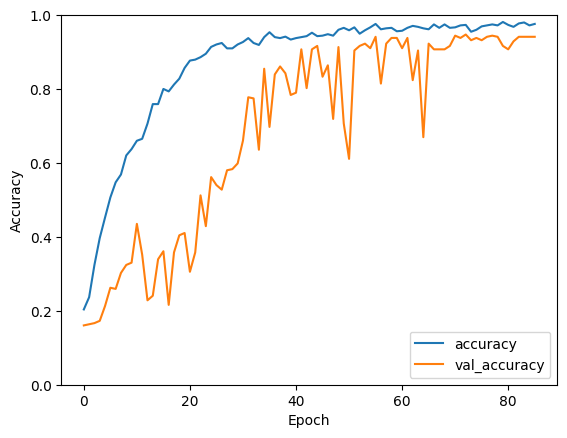

In [430]:
plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [431]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score

In [432]:
cm = confusion_matrix(y_test,y_pred, labels=[0,1,2,3,4,5])  
print(cm)

[[20  0  0  0  0  0]
 [ 0 20  0  0  0  0]
 [ 0  2 18  0  0  0]
 [ 0  0  0 20  0  0]
 [ 0  0  0  1 18  1]
 [ 0  0  0  0  0 20]]


In [433]:
ber = 1-balanced_accuracy_score(y_test, y_pred)

In [434]:
ber

0.033333333333333326

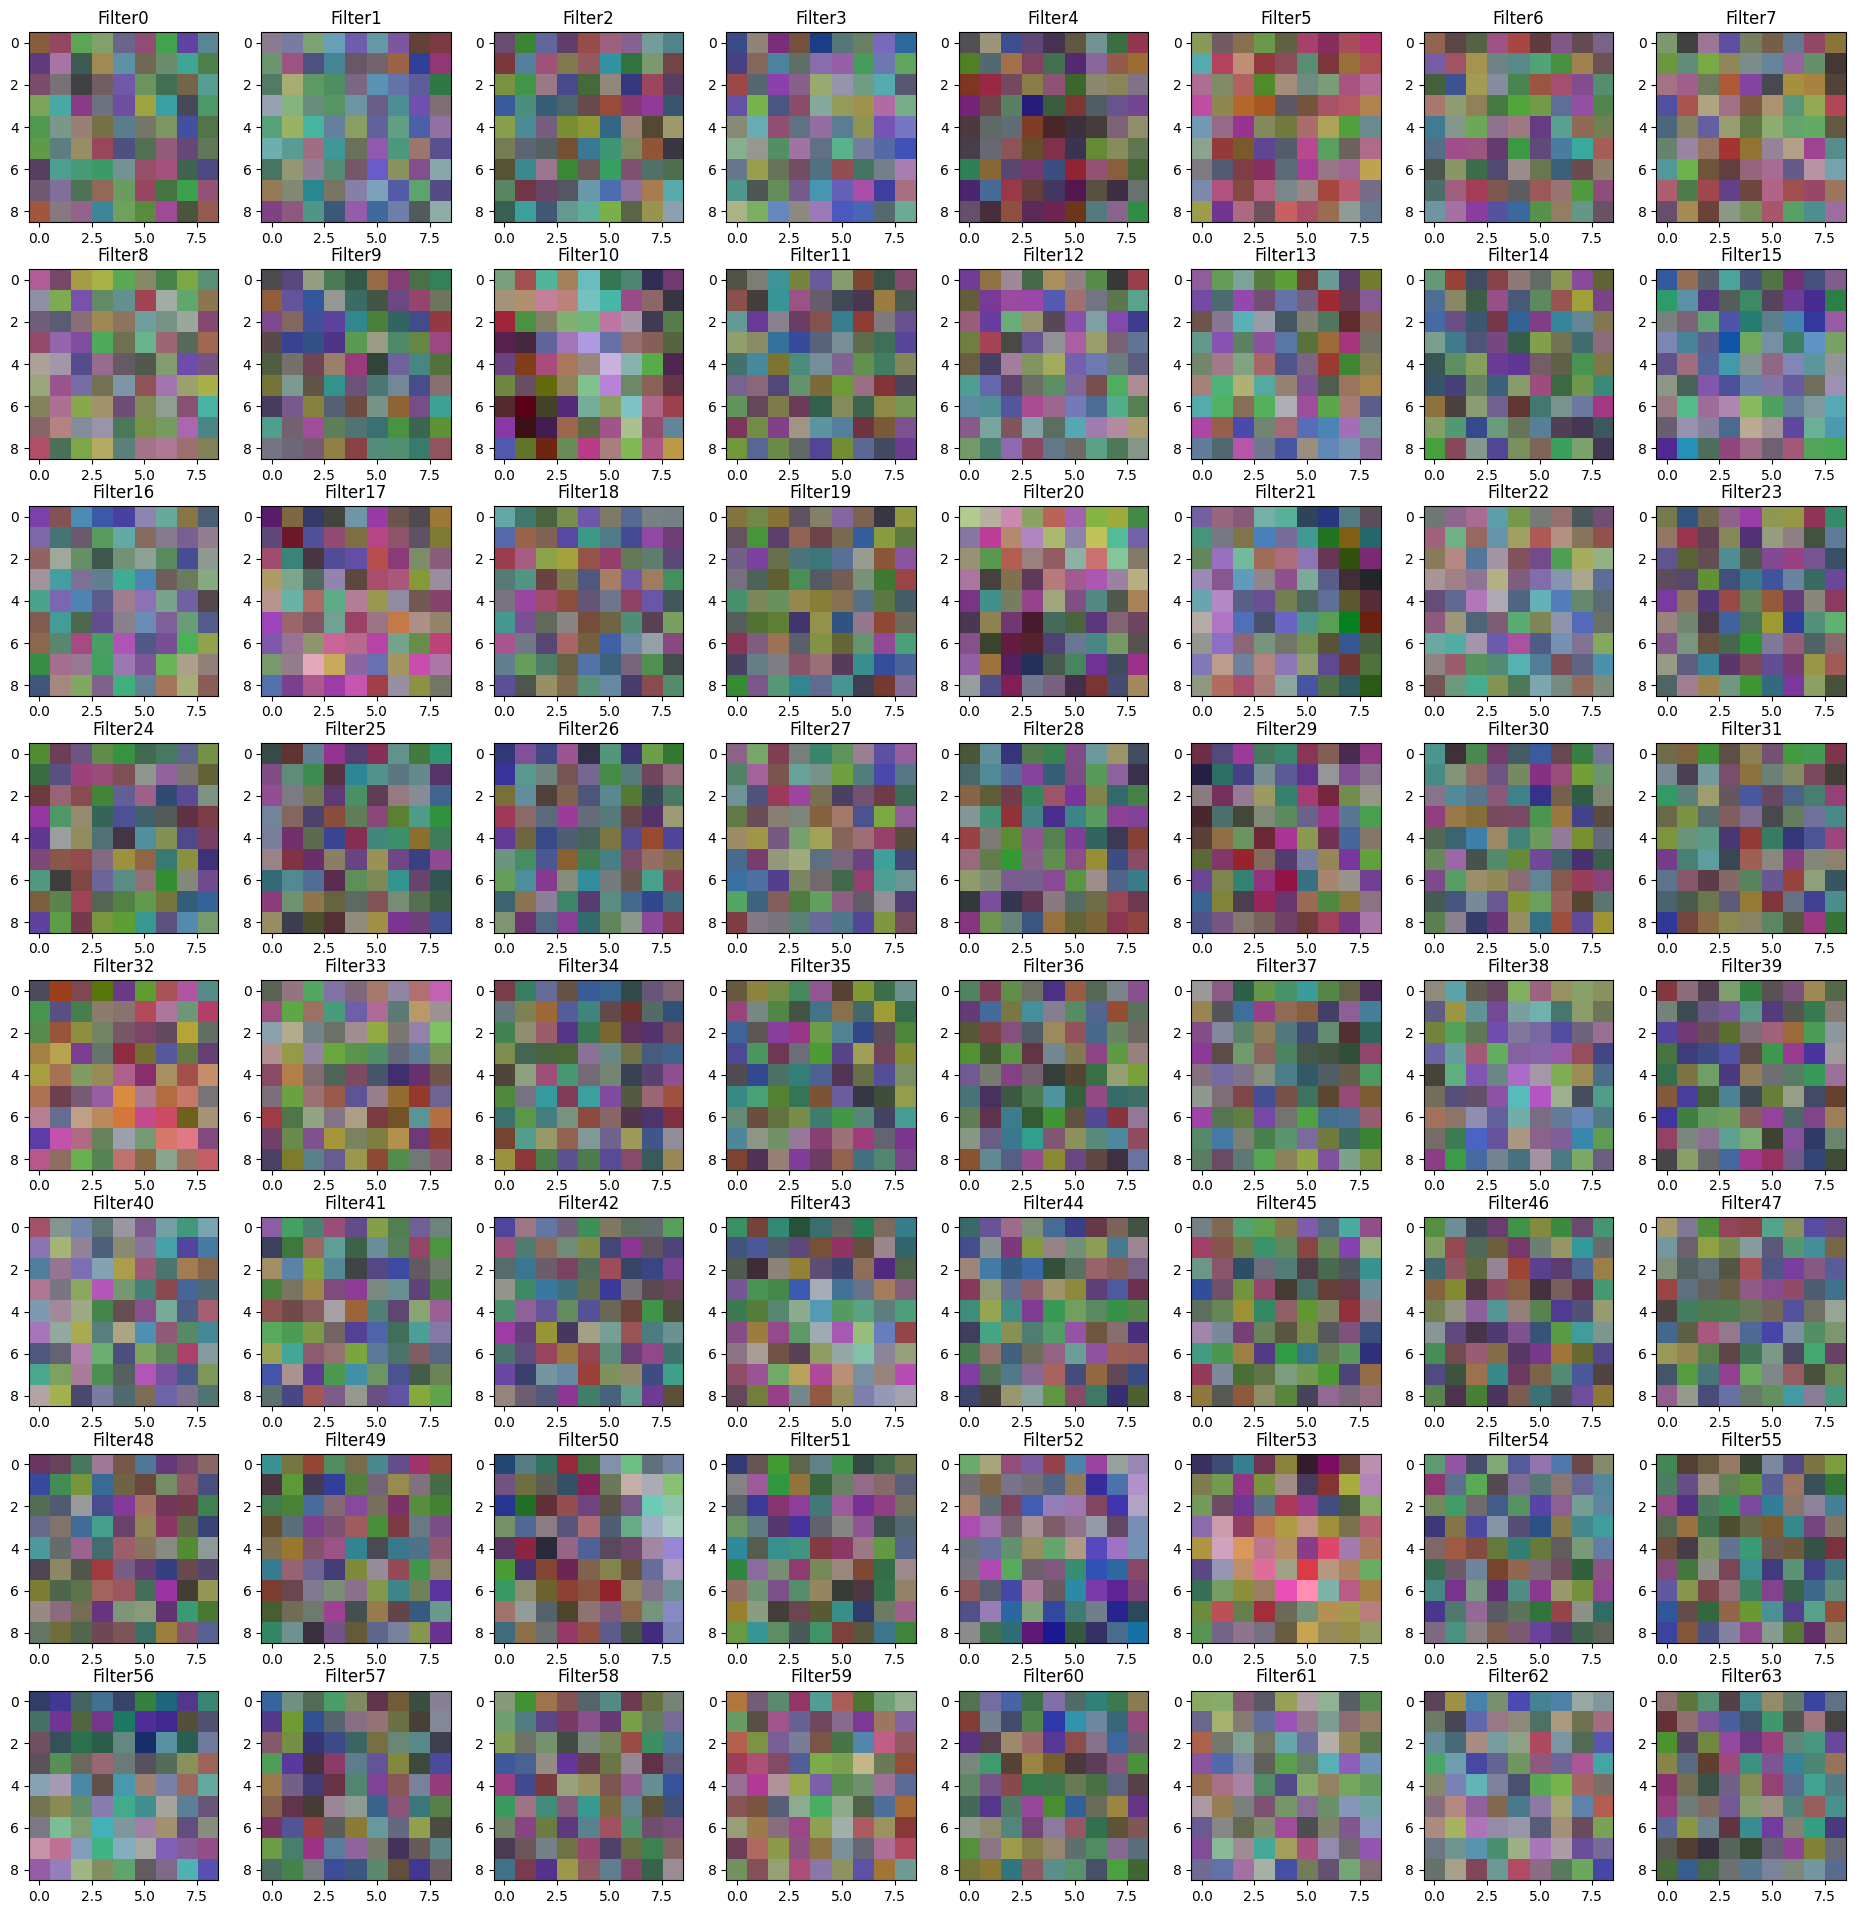

In [435]:
from sklearn.preprocessing import MinMaxScaler
cnn11 = classifier.layers[1].name # get the name of the 1st convolutional layer
w =classifier.get_layer(name=cnn11).get_weights()[0] # get the filters
wshape = w.shape # save the original shape
# we will scale to [0,1] for visualization purposes
scaler = MinMaxScaler()
scaler.fit(w.reshape(-1,1))
w = scaler.transform(w.reshape(-1,1))
w = w.reshape(wshape)
# we will display them 8x8
fig,axs = plt.subplots(8,8,figsize=(24,24))
fig.subplots_adjust(hspace=.25, wspace=.001)
axs = axs.ravel()
for i in range(w.shape[-1]):
  #we will reshape to a 3D (RGB) image shape and display
  h=np.reshape(w[:,:,:,i],(9,9,3))
  axs[i].imshow(h)
  axs[i].set_title('Filter'+str(i))